In [ ]:
!pip install ucimlrepo

missing values:
 Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
dtype: int64

duplicate records: 0

Descriptive Statistics:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000


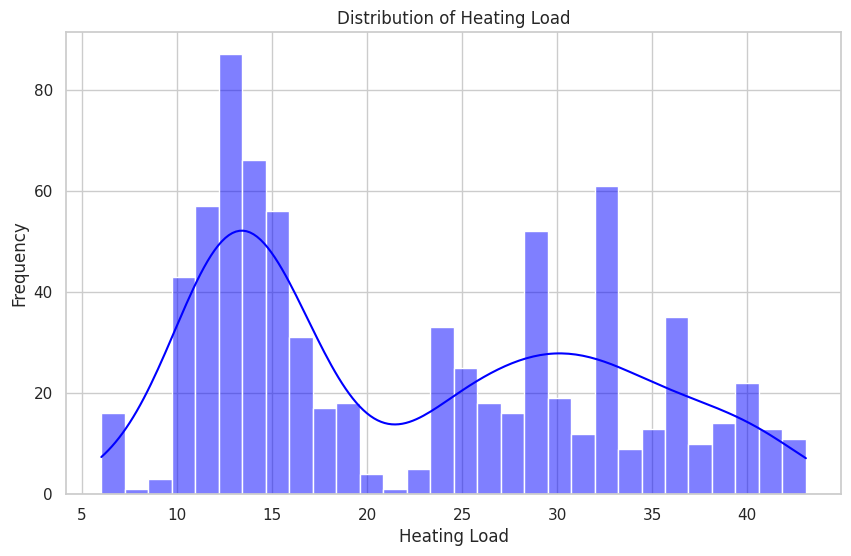

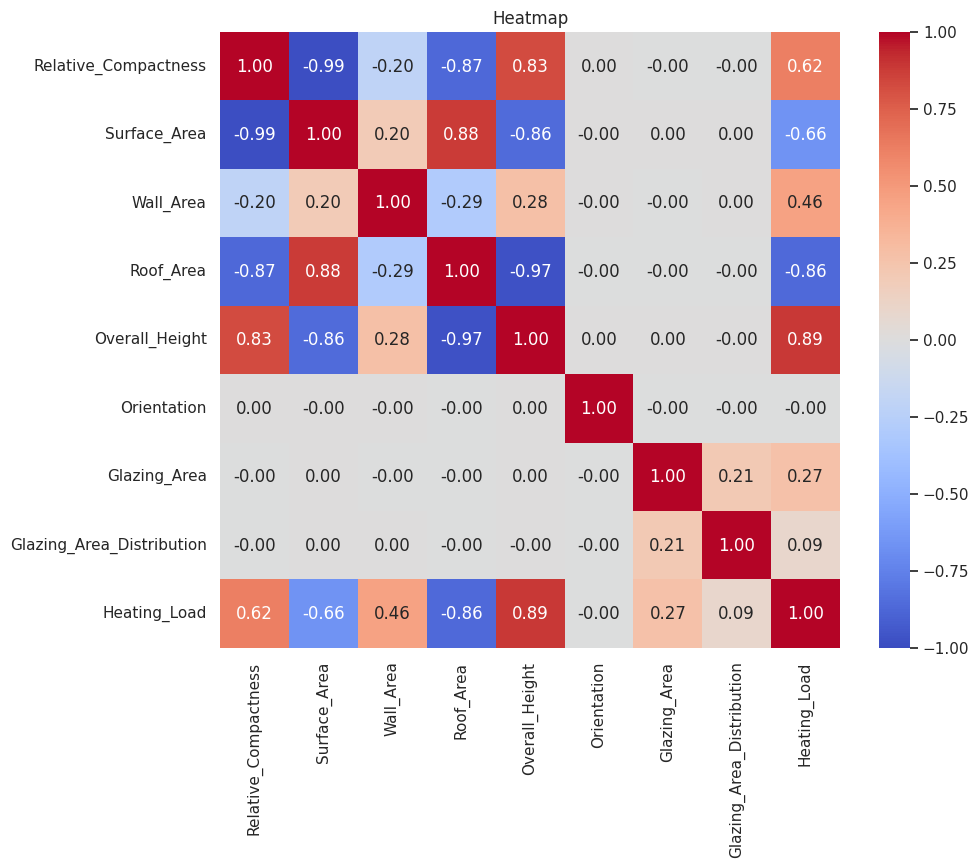

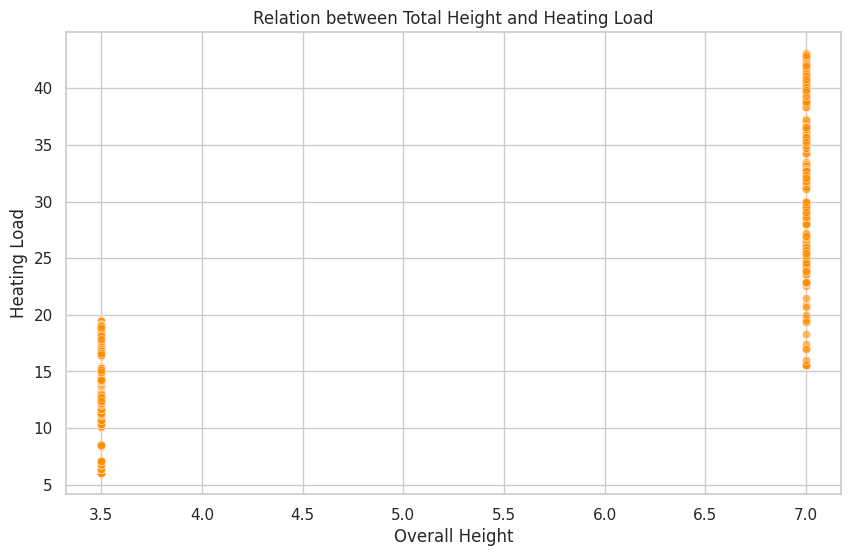

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

energy_efficiency = fetch_ucirepo(id=242)

# data (as pandas dataframes)
X_raw = energy_efficiency.data.features
y_raw = energy_efficiency.data.targets

# temporarily join the features and the targets into one DataFrame.
df = pd.concat([X_raw, y_raw], axis=1)

column_names = {
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
}
df = df.rename(columns=column_names)

# We keep only the Heating_Load delete the Cooling_Load
if 'Cooling_Load' in df.columns:
    df = df.drop('Cooling_Load', axis=1)


# Check for missing values
print("missing values:\n", df.isnull().sum())

# Check for duplicate records and outliers.
print("\nduplicate records:", df.duplicated().sum())

df = df.drop_duplicates()

# Descriptive Statistics
print("\nDescriptive Statistics:")
display(df.describe())

# Visualizations

# histogram
plt.figure()
sns.histplot(df['Heating_Load'], kde=True, bins=30, color='blue')
plt.title('Distribution of Heating Load')
plt.xlabel('Heating Load')
plt.ylabel('Frequency')
plt.show()

# Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap')
plt.show()

# Scatter plot
plt.figure()
sns.scatterplot(data=df, x='Overall_Height', y='Heating_Load', alpha=0.6, color='darkorange')
plt.title('Relation between Total Height and Heating Load')
plt.xlabel('Overall Height')
plt.ylabel('Heating Load')
plt.show()

In [ ]:
# 2. Data Preprocessing


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into features (X) and target (y)
X = df.drop('Heating_Load', axis=1)
y = df['Heating_Load']

# Train / test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

# data leakage bypassing
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Διαστάσεις X_train_scaled: {X_train_scaled.shape}")
print(f"Διαστάσεις X_test_scaled: {X_test_scaled.shape}")

Διαστάσεις X_train_scaled: (614, 8)
Διαστάσεις X_test_scaled: (154, 8)


In [ ]:
# 3. Baseline model creation

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train models with initial/default settings
# Added random_state to the trees for full reproducibility
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR()
}

results_list = []

# Training
for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    # test set prediction
    y_pred = model.predict(X_test_scaled)

    # Calculation of metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse) # square root of MSE
    r2 = r2_score(y_test, y_pred)

    results_list.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R^2": r2
    })

# Comparative table of results
results_df = pd.DataFrame(results_list)

# Sorting the table based on $R^2$ (from best to worst).
results_df = results_df.sort_values(by="R^2", ascending=False).reset_index(drop=True)

print("Comparative table of results:\n")
display(results_df)

Comparative table of results:



,Model,MAE,MSE,RMSE,R^2
0,Random Forest,0.358216,0.247322,0.497315,0.997627
1,Gradient Boosting,0.386159,0.265312,0.515084,0.997455
2,Decision Tree,0.419740,0.388012,0.622906,0.996277
3,SVR,1.888638,7.969665,2.823060,0.923539
4,Linear Regression,2.182047,9.153188,3.025424,0.912184


In [ ]:
# 4. Cross-validation

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline

# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

cv_results_list = []

# cross-validation for each model
for name, model in models.items():

    # Pipeline:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    cv_scores = cross_validate(pipeline, X_train, y_train, cv=kf, scoring=scoring)

    # (I multiply the errors with -1 because scikit learn returns them negative)
    mean_r2 = cv_scores['test_R2'].mean()
    std_r2 = cv_scores['test_R2'].std()

    mean_rmse = -cv_scores['test_RMSE'].mean()
    std_rmse = cv_scores['test_RMSE'].std()

    mean_mae = -cv_scores['test_MAE'].mean()
    std_mae = cv_scores['test_MAE'].std()

    mean_mse = -cv_scores['test_MSE'].mean()
    std_mse = cv_scores['test_MSE'].std()

    cv_results_list.append({
        "Model": name,
        "R^2 (Mean ± Std)": f"{mean_r2:.4f} ± {std_r2:.4f}",
        "RMSE (Mean ± Std)": f"{mean_rmse:.4f} ± {std_rmse:.4f}",
        "MAE (Mean ± Std)": f"{mean_mae:.4f} ± {std_mae:.4f}",
        "MSE (Mean ± Std)": f"{mean_mse:.4f} ± {std_mse:.4f}",
        "Raw_R2_Mean": mean_r2 # for sorting
    })

# Creation and display of the comparative table.
cv_results_df = pd.DataFrame(cv_results_list)

# Sorting based on the mean value of R^2
cv_results_df = cv_results_df.sort_values(by="Raw_R2_Mean", ascending=False).drop('Raw_R2_Mean', axis=1).reset_index(drop=True)

print("5-Fold Cross Validation results:")
display(cv_results_df)

5-Fold Cross Validation results:


,Model,R^2 (Mean ± Std),RMSE (Mean ± Std),MAE (Mean ± Std),MSE (Mean ± Std)
0,Gradient Boosting,0.9975 ± 0.0004,0.4945 ± 0.0375,0.3500 ± 0.0106,0.2459 ± 0.0373
1,Random Forest,0.9974 ± 0.0003,0.5130 ± 0.0342,0.3417 ± 0.0302,0.2643 ± 0.0347
2,Decision Tree,0.9967 ± 0.0003,0.5760 ± 0.0274,0.3735 ± 0.0249,0.3325 ± 0.0315
3,SVR,0.9180 ± 0.0081,2.8610 ± 0.1001,1.9180 ± 0.0921,8.1951 ± 0.5723
4,Linear Regression,0.9146 ± 0.0109,2.9158 ± 0.1590,2.0618 ± 0.0950,8.5273 ± 0.9352


Filter Method: Mutual Information


,Feature,MI_Score
0,Surface_Area,1.599944
1,Relative_Compactness,1.592985
2,Wall_Area,1.012278
3,Roof_Area,0.859587
4,Glazing_Area,0.653517
5,Overall_Height,0.650941
6,Glazing_Area_Distribution,0.127923
7,Orientation,0.000000


/tmp/ipykernel_6048/3109371779.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')


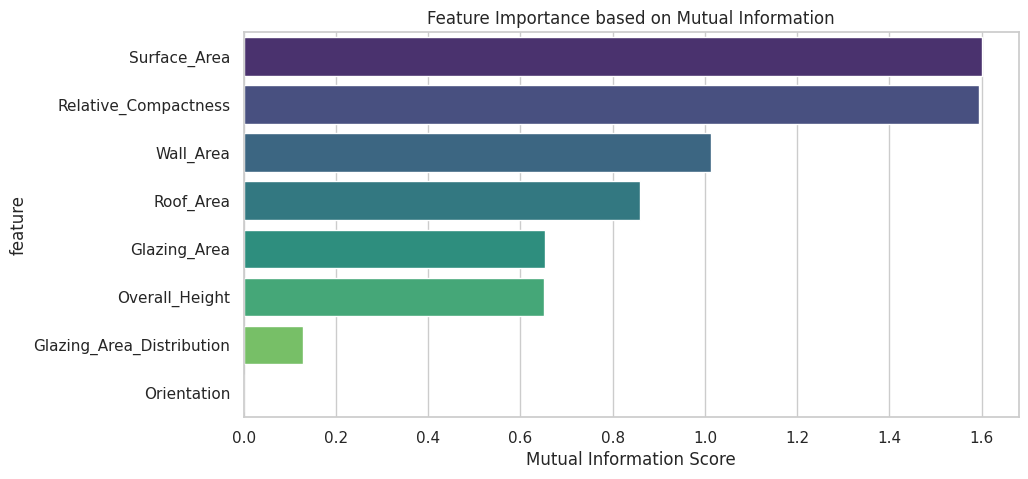


 Wrapper Method: Recursive Feature Elimination


,Feature,Selected,Ranking
0,Relative_Compactness,True,1
1,Surface_Area,True,1
2,Roof_Area,True,1
3,Overall_Height,True,1
4,Glazing_Area,False,2
5,Wall_Area,False,3
6,Glazing_Area_Distribution,False,4
7,Orientation,False,5



Selected features (RFE Top 4): ['Relative_Compactness', 'Surface_Area', 'Roof_Area', 'Overall_Height']

 Performance Comparison


,Model: Random Forest,R^2,RMSE
0,With 8 features,0.997627,0.497315
1,With 4 (RFE),0.910354,3.056788


In [ ]:
# 5. Feature Selection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Filter Method: Mutual Information")

# Calculation of mutual information(mi)
mi_scores = mutual_info_regression(X_train_scaled, y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': X_train_scaled.columns, 'MI_Score': mi_scores})

# Sorting from most important to least important.
mi_df = mi_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)
display(mi_df)

# Visualization with barplot
plt.figure(figsize=(10, 5))
sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
plt.title('Feature Importance based on Mutual Information')
plt.xlabel('Mutual Information Score')
plt.ylabel('feature')
plt.show()

print("\n Wrapper Method: Recursive Feature Elimination")

# We use a Random Forest as the estimator to select the features.
rfe_estimator = RandomForestRegressor(random_state=42)

# We request the method to keep the 4 most important features.
rfe = RFE(estimator=rfe_estimator, n_features_to_select=4, step=1)
rfe.fit(X_train_scaled, y_train)

# Creation of a table with the RFE ranking(ranking 1 means it was selected).
rfe_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
})
rfe_df = rfe_df.sort_values(by='Ranking').reset_index(drop=True)
display(rfe_df)

# We keep the names of the selected features
selected_features = rfe_df[rfe_df['Selected'] == True]['Feature'].tolist()
print(f"\nSelected features (RFE Top 4): {selected_features}")

print("\n Performance Comparison")

model_all = RandomForestRegressor(random_state=42)
model_sel = RandomForestRegressor(random_state=42)

# 1. Training and evaluation using all 8 features
model_all.fit(X_train_scaled, y_train)
y_pred_all = model_all.predict(X_test_scaled)
r2_all = r2_score(y_test, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))

# 2. Training and evaluation using the 4 selected features
X_train_sel = X_train_scaled[selected_features]
X_test_sel = X_test_scaled[selected_features]

model_sel.fit(X_train_sel, y_train)
y_pred_sel = model_sel.predict(X_test_sel)
r2_sel = r2_score(y_test, y_pred_sel)
rmse_sel = np.sqrt(mean_squared_error(y_test, y_pred_sel))

# Creation of comparative table
comparison_df = pd.DataFrame({
    "Model: Random Forest": ["With 8 features", "With 4 (RFE)"],
    "R^2": [r2_all, r2_sel],
    "RMSE": [rmse_all, rmse_sel]
})

display(comparison_df)

In [ ]:
# 6. Hyperparameter tuning

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# random forest and gradient boosting

# Definition of the search space (Grid)
# For the Random Forest we test the number of trees, the maximum depth, and the minimum samples for splitting.
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# For Gradient Boosting we test the number of trees, the learning rate, and the maximum depth.
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Hyperparameter search
print(f"Random Forest Grid: {rf_param_grid}")
print(f"Gradient Boosting Grid: {gb_param_grid}\n")

# Grid Search
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=5, scoring='r2', n_jobs=-1)
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=5, scoring='r2', n_jobs=-1)

# Grid Search train
rf_grid.fit(X_train_scaled, y_train)
gb_grid.fit(X_train_scaled, y_train)

print("\n Best Hyperparameters")
print(f"Best Random Forest: {rf_grid.best_params_}")
print(f"Best Gradient Boosting: {gb_grid.best_params_}\n")

# Performance Comparison(before and after)
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return r2, rmse

# Simple models evaluation
rf_default = RandomForestRegressor(random_state=42).fit(X_train_scaled, y_train)
gb_default = GradientBoostingRegressor(random_state=42).fit(X_train_scaled, y_train)

rf_def_r2, rf_def_rmse = evaluate_model(rf_default, X_test_scaled, y_test)
gb_def_r2, gb_def_rmse = evaluate_model(gb_default, X_test_scaled, y_test)

# optimized models evaluation
rf_tuned = rf_grid.best_estimator_
gb_tuned = gb_grid.best_estimator_

rf_tun_r2, rf_tun_rmse = evaluate_model(rf_tuned, X_test_scaled, y_test)
gb_tun_r2, gb_tun_rmse = evaluate_model(gb_tuned, X_test_scaled, y_test)

# Creation of comparative table
tuning_results = pd.DataFrame({
    "Model Status": ["Random Forest (Default)", "Random Forest (Tuned)", "Gradient Boosting (Default)", "Gradient Boosting (Tuned)"],
    "R^2": [rf_def_r2, rf_tun_r2, gb_def_r2, gb_tun_r2],
    "RMSE": [rf_def_rmse, rf_tun_rmse, gb_def_rmse, gb_tun_rmse]
})

print("\n Performance Comparison: before and after tuning")
display(tuning_results)

Random Forest Grid: {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}
Gradient Boosting Grid: {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 4, 5]}


 Best Hyperparameters
Best Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}


 Performance Comparison: before and after tuning


,Model Status,R^2,RMSE
0,Random Forest (Default),0.997627,0.497315
1,Random Forest (Tuned),0.997614,0.498688
2,Gradient Boosting (Default),0.997455,0.515084
3,Gradient Boosting (Tuned),0.998365,0.412787


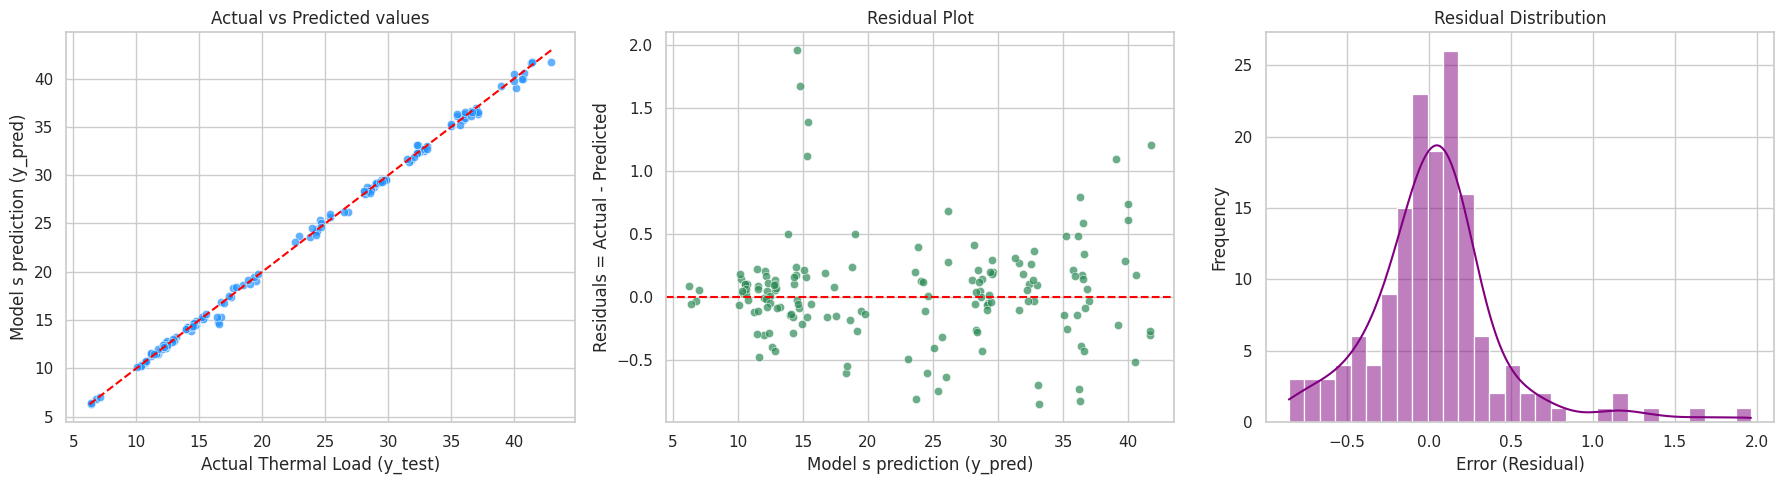


 The 3 observations with the largest prediction error: 


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Actual_Load,Predicted_Load,Residual
764,0.62,808.5,367.5,220.5,3.5,2,0.4,5,16.54,14.576672,1.963328
668,0.62,808.5,367.5,220.5,3.5,2,0.4,3,16.47,14.793384,1.676616
620,0.62,808.5,367.5,220.5,3.5,2,0.4,2,16.76,15.369148,1.390852


In [ ]:
# 7. Error analysis and diagnostic checks

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# We use the best model(tuned Gradient Boosting)
best_model = gb_grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)
residuals = y_test - y_pred

plt.figure(figsize=(18, 5))

# Actual vs Predicted values plot
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='dodgerblue')
# addition of y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.title('Actual vs Predicted values')
plt.xlabel('Actual Thermal Load (y_test)')
plt.ylabel('Model s prediction (y_pred)')

# Residual Plot
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, color='seagreen')
plt.axhline(y=0, color='red', linestyle='--') # Zero error line
plt.title('Residual Plot')
plt.xlabel('Model s prediction (y_pred)')
plt.ylabel('Residuals = Actual - Predicted')

# Histogram
plt.subplot(1, 3, 3)
sns.histplot(residuals, kde=True, bins=30, color='purple')
plt.title('Residual Distribution')
plt.xlabel('Error (Residual)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Identification of the 3 observations with the largest error
error_analysis_df = X_test.copy()
error_analysis_df['Actual_Load'] = y_test
error_analysis_df['Predicted_Load'] = y_pred
error_analysis_df['Residual'] = residuals
error_analysis_df['Abs_Residual'] = np.abs(residuals) # absolut error

# Sorting by absolute error (descending order) and selecting the top 3.
top_3_errors = error_analysis_df.sort_values(by='Abs_Residual', ascending=False).head(3)

print("\n The 3 observations with the largest prediction error: ")
display(top_3_errors.drop('Abs_Residual', axis=1))

Linear Regression Coefficients


,Feature,Coefficient
0,Overall_Height,7.215464
1,Relative_Compactness,-6.517601
2,Roof_Area,-3.917367
3,Surface_Area,-3.604586
4,Glazing_Area,2.700051
5,Wall_Area,0.795339
6,Glazing_Area_Distribution,0.327345
7,Orientation,-0.035934



 Feature Importance from Gradient Boosting


,Feature,Importance
0,Relative_Compactness,0.473640
1,Overall_Height,0.335954
2,Glazing_Area,0.075432
3,Surface_Area,0.052224
4,Wall_Area,0.026795
5,Roof_Area,0.021379
6,Glazing_Area_Distribution,0.014192
7,Orientation,0.000383


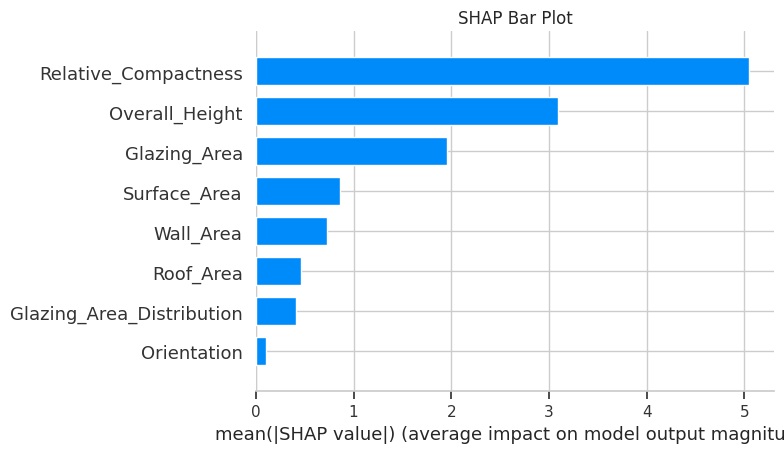

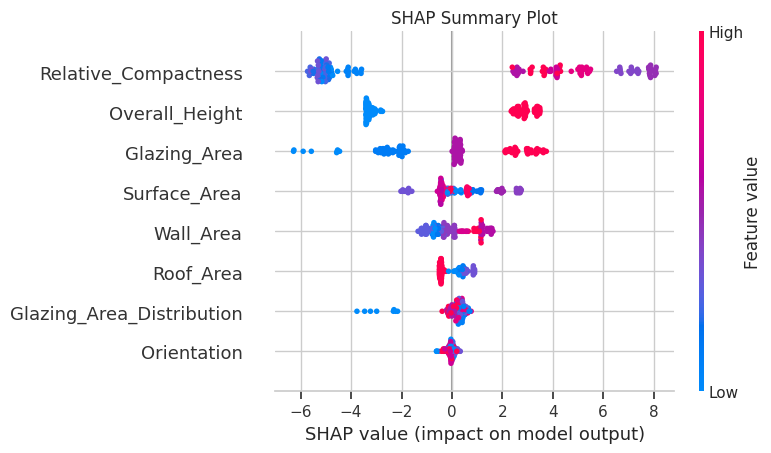

In [ ]:
# Model Interpretability

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 8.1 Linear model
print("Linear Regression Coefficients")
lin_reg = LinearRegression().fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lin_reg.coef_
})
# Sorting based on the absolute value of the coefficient
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False).reset_index(drop=True)
display(coef_df)

# Feature Importance (in ensemble model)
print("\n Feature Importance from Gradient Boosting")
best_model = gb_grid.best_estimator_

importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)
display(importance_df)

# SHAP
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP Bar Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Bar Plot")
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.show()

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot")
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.show()